Dataset Preview
   Vehicle_Count  Signal_Time  Road_Block Traffic_Status
0             24            8           1           High
1             58            3           1           High
2             69            3           0         Medium
3             36            1           0            Low
4             57            3           0         Medium

Model Accuracy: 1.0

Enter Traffic Details


Vehicle Count:  45
Signal Waiting Time:  3
Road Block (0-No / 1-Yes):  1



Predicted Traffic Status: High
Heavy Traffic Detected


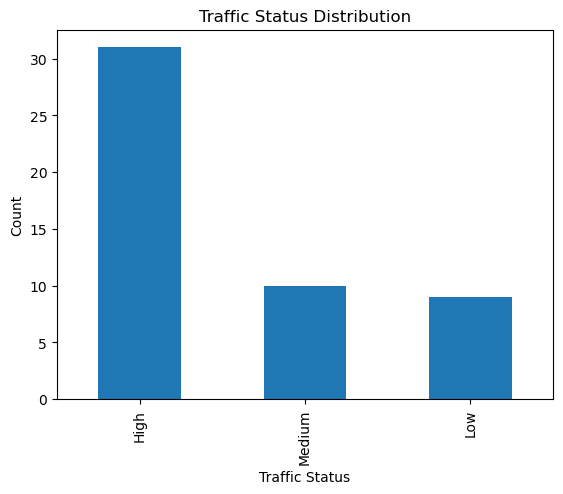

In [3]:
#### import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data = pd.read_csv("traffic_data.csv")

print("Dataset Preview")
print(data.head())

X = data.drop("Traffic_Status", axis=1)
y = data["Traffic_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:", accuracy)

print("\nEnter Traffic Details")

vehicle_count = int(input("Vehicle Count: "))
signal_time = int(input("Signal Waiting Time: "))
road_block = int(input("Road Block (0-No / 1-Yes): "))

user_data = pd.DataFrame([[
    vehicle_count,
    signal_time,
    road_block
]], columns=[
    "Vehicle_Count",
    "Signal_Time",
    "Road_Block"
])

prediction = model.predict(user_data)

print("\nPredicted Traffic Status:", prediction[0])

if prediction[0] == "High":
    print("Heavy Traffic Detected")
elif prediction[0] == "Medium":
    print("Moderate Traffic Detected")
else:
    print("Low Traffic Detected")

data["Traffic_Status"].value_counts().plot(kind="bar")

plt.title("Traffic Status Distribution")
plt.xlabel("Traffic Status")
plt.ylabel("Count")

plt.show()